[![Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/blob/main/notebook.ipynb)

## Libraries

In [72]:
import torch
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter(action='ignore')
import numpy as np
import os
import random
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"       # to force BERT determinsm

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # per multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)

## Download Github files

In [73]:
try:
    import google.colab
    %mkdir data
    %mkdir scripts
    %mkdir results
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/data/INA_dataset.json -O data/INA_dataset.json
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/scripts/models.py -O scripts/models.py
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/scripts/utils.py -O scripts/utils.py
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/scripts/embedding.py -O scripts/embedding.py
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/scripts/cv_folding.py -O scripts/cv_folding.py
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/scripts/configure.py -O scripts/configure.py
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/scripts/plotting.py -O scripts/plotting.py
    print("Working on Colab!")
except:
    print("Not Working on Colab ... or cannot dwnload Githb files!")
    pass

Not Working on Colab ... or cannot dwnload Githb files!


## Load dataset

In [74]:
import sys, os

DATA_PATH = "data" # "your-path-to-data"
dataset = "MIMIC"
if dataset == "INA":
    datafile =  "INA_dataset.json"
    target_var = "is_alive?"
    evfields = ['code_descr']
    static_vars = ["gender", "age_group", "primary_disease"]
    disease_list = ["SCD", "CHA", "NHOC", "AS", "AHD", "NTDT", "IM", "TDT", "OD"]
    remove_events = ['followup', 'platelet_change', 'bmi_change', 'thrombosys']
    thresh = 0.3
elif dataset == "MIMIC":
    datafile = "MIMIC_dataset.json"
    static_vars = ["gender", "age_at_splenectomy", "primary_disease"]
    disease_list = ["OD", "CHA", "SP", "THA", "AHD", "SCD"]
    target_var = "is_alive?"
    evfields = ['event']
    remove_events = ['drug']
    thresh = 0.3
else:
    raise Exception("dataset not supported!")

class settings:
  def __init__(self, datafile):
    self.dataset = pd.read_json(datafile)
    self.pathology_field = 'primary_disease'
    self.static_vars= static_vars
    self.target_var = target_var
    self.evfields = evfields
    self.remove_events = remove_events
    self.enable_plot=True
    self.n_splits=5
    self.num_epochs=10
    self.batch_size = 16
    self.embedding_dim=128
    self.hidden_dim=300
    self.random_state=42
    self.save = False
    self.iter=5
    self.results_dir="results"

args = settings(os.path.join(DATA_PATH, datafile))
args.dataset.head(20)

,id,gender,age_group,is_splenectomized?,age_at_splenectomy,primary_disease,is_alive?,cause_of_death,events
0,10004235,M,mature,NO,None,OD - Oncological Diseases,YES,None,"[{'type': 'infection', 'event': 'Septicemia du..."
1,10004401,M,geriatric,NO,None,CHA - Congenital Hemolytic Anemias,NO,Chronic or unspecified duodenal ulcer with hem...,"[{'type': 'disease', 'event': 'Acute posthemor..."
2,10008460,F,elder,NO,None,OD - Oncological Diseases,YES,None,"[{'type': 'disease', 'event': 'Endometrial int..."
3,10008924,F,mature,NO,None,OD - Oncological Diseases,YES,None,"[{'type': 'disease', 'event': 'Spontaneous bac..."
4,10015701,F,geriatric,NO,None,OD - Oncological Diseases,YES,None,"[{'type': 'disease', 'event': 'Other malignant..."
5,10015988,M,geriatric,YES,None,OD - Oncological Diseases,YES,None,"[{'type': 'infection', 'event': 'Pneumonia due..."
6,10018862,F,elder,NO,None,OD - Oncological Diseases,YES,None,"[{'type': 'disease', 'event': 'Epigastric pain..."
7,10019003,F,elder,NO,None,OD - Oncological Diseases,YES,None,"[{'type': 'disease', 'event': 'Other and unspe..."
8,10023486,M,elder,NO,None,OD - Oncological Diseases,YES,None,"[{'type': 'disease', 'event': 'Major laceratio..."
9,10024451,M,elder,NO,None,OD - Oncological Diseases,YES,None,"[{'type': 'disease', 'event': 'Cholangitis', '..."


### Plot dataset distributions

<Figure size 640x480 with 0 Axes>

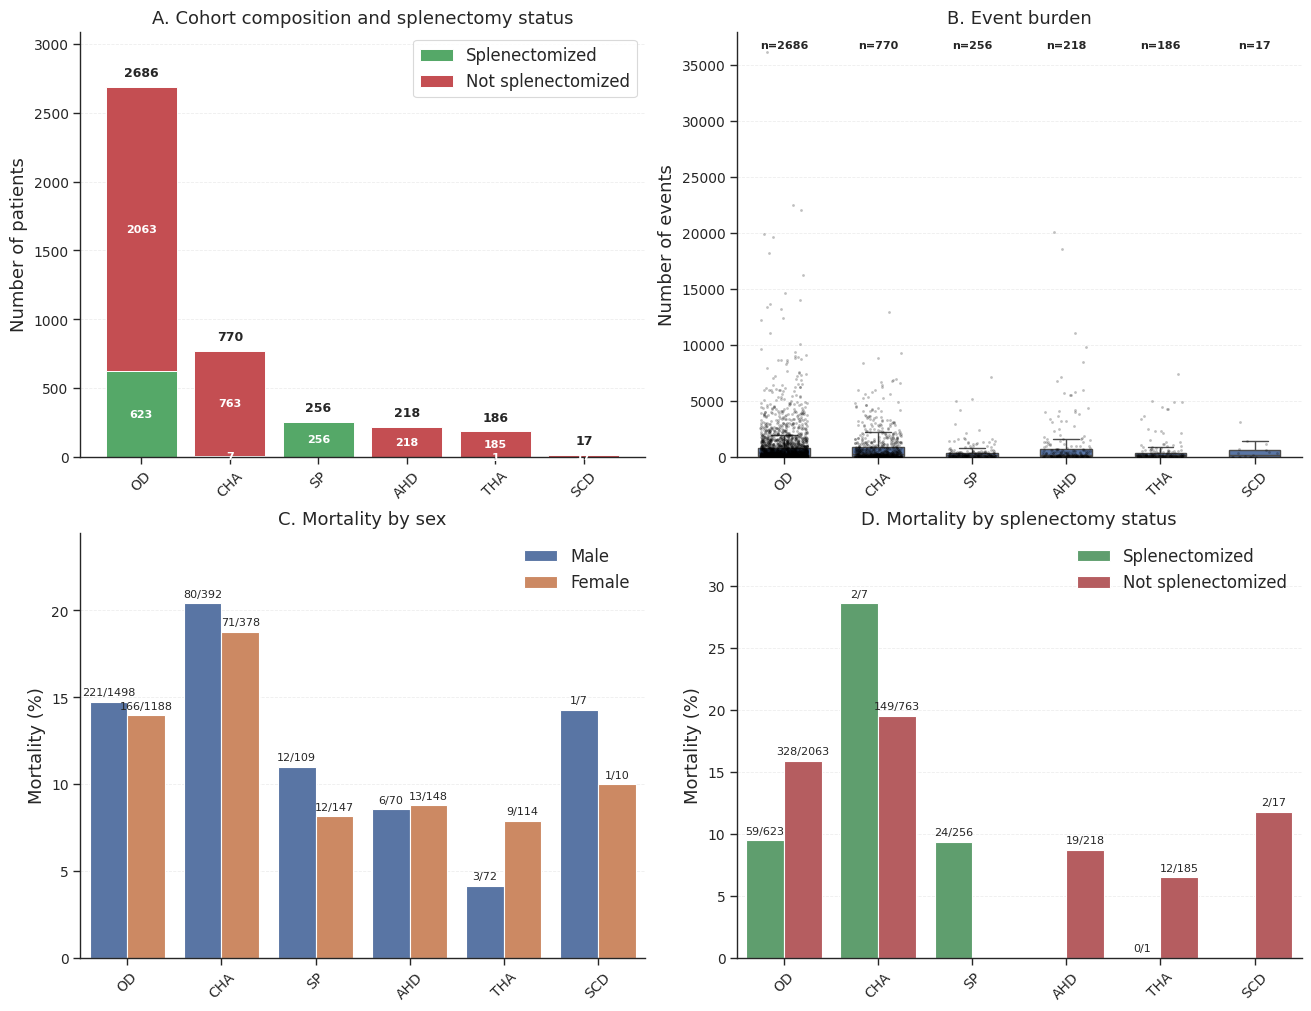

In [75]:
from scripts.plotting import plot_distrib
fig = plot_distrib(args.dataset, dict(zip(list(args.dataset["primary_disease"].unique()), disease_list)))

### Select splenectomize patients

In [76]:
args.dataset = args.dataset[args.dataset["is_splenectomized?"] == 'YES']
args.selected_patient_ids = args.dataset.index
print("Splenectomized Patients no:", len(args.selected_patient_ids))

Splenectomized Patients no: 887


### Remove patients with specific cause of death

In [77]:
if "cause_of_death" in args.dataset.columns:
    words = ["accident", "trauma", "suicide", "fracture", "malignant", "myeloma"]
    pattern = "|".join(words)
    args.dataset = args.dataset[~args.dataset["cause_of_death"].str.contains(pattern, case=False, na=False)]
    args.selected_patient_ids = args.dataset.index
    print("Patients no:", len(args.selected_patient_ids))

Patients no: 872


### Remove patients with no events

In [78]:
args.dataset = args.dataset[args.dataset["events"].apply(lambda x: x != [])]
args.selected_patient_ids = args.dataset.index
print("Patients no:", len(args.selected_patient_ids))

Patients no: 872


## Get clinical trajectories

In [79]:
from scripts.utils import count_events_by_type
events_field, date_field, type_field = 'events', 'date', 'type'
event_sequences = { id: [(" ".join([event[field] if isinstance(event[field], str) else "NONE" for field in args.evfields]), 
    event[date_field], event[type_field]) for event in events] for (id,events) in args.dataset[[events_field]].to_dict()[events_field].items()} 

### Remove events by types

In [80]:
from scripts.utils import group_events_by_visit
# get sequence of event names
event_sequences = { id: [(" ".join([event[field] if isinstance(event[field], str) else "NONE" for field in args.evfields]), event[date_field]) for event in events if event[type_field] not in args.remove_events] for (id,events) in args.dataset[[events_field]].to_dict()[events_field].items()} 
event_sequences_type = { id: [(" ".join([event[field] if isinstance(event[field], str) else "NONE" for field in args.evfields]), event[date_field], event[type_field]) for event in events if event[type_field] not in args.remove_events] for (id,events) in args.dataset[[events_field]].to_dict()[events_field].items()} 
visit_sequences = group_events_by_visit(event_sequences)
args.dataset['events'] = args.dataset.apply(lambda row: event_sequences[row.name], axis=1)
print(f"n.{len(event_sequences)} Patients")

n.872 Patients


In [81]:
event_sequences = { id: events for (id,events) in event_sequences.items() if len(events) > 0 } 
event_sequences_type = { id: events for (id,events) in event_sequences_type.items() if len(events) > 0 }
args.selected_patient_ids = np.array(list(event_sequences.keys()))

### count event by type and cardinality

In [82]:
count_events_by_type(event_sequences_type)

,cardinality,n. instances,set
type,,,
infection,423,3833,"{Infection of colostomy or enterostomy, Pneumo..."
disease,5164,62694,"{Enterostomy malfunction, Anemia due to glucos..."
surgery,515,2031,{Other and unspecified segmental resection of ...
therapy,1395,7205,"{Transplant from live related donor, Exchange ..."
vaccination,25,1859,"{Fluoxetine, Hepatitis B Vaccine, Fludrocortis..."


## Get static variables

In [83]:
if len(args.static_vars) > 0:
    mapper = {'pediatric': 0, 'adolescent' : 1, 'adult': 2, 'ND' : -1, 'young': 0, 'mature' : 1, 'elder': 2, 'geriatric': 3}
    X_static = args.dataset.loc[args.selected_patient_ids][args.static_vars].copy()
    X_static.replace(mapper, inplace=True)
    cnames = list(X_static.select_dtypes(include=['object']).columns)
    for col in cnames:
        X_static[col], _ = pd.factorize(X_static[col])
else:
    X_static = pd.DataFrame(index=args.selected_patient_ids)
X_static

,gender,age_at_splenectomy,primary_disease
5,0,NaN,0
12,0,2.0,1
14,0,NaN,0
31,0,0.0,1
32,1,0.0,0
...,...,...,...
4117,1,NaN,0
4118,0,2.0,1
4121,0,1.0,0
4126,1,3.0,1


## Get targets

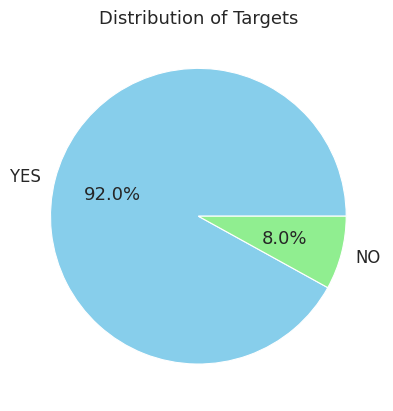

In [84]:
import matplotlib.pyplot as plt
target_df = args.dataset[args.target_var].copy()
target_df.replace({"n/a": "YES", np.nan: "YES"}, inplace=True)
counts = target_df.value_counts()
counts.plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'lightgreen'])
plt.title('Distribution of Targets')
plt.ylabel('')
target_df.replace({"YES": 0, "NO": 1}, inplace=True)
target_df.to_csv(os.path.join(DATA_PATH, f"{dataset}_targets.csv"))
plt.show()

In [85]:
from scripts.configure import configure
embedder_configs = configure(event_sequences, visit_sequences, event_sequences_type, target_df.to_dict(), X_static, args)

# Create empty dataframe for results collections
cols = ["AUC mean","AUC std","F1 mean","F1 std","Prec mean","Prec std","Recall mean","Recall std","MCC mean","MCC std","Acc mean","Acc std","CM"]
dtypes = {"AUC mean": "float64", "AUC std": "float64","F1 mean": "float64","F1 std": "float64","Prec mean": "float64","Prec std": "float64","Recall mean": "float64","Recall std": "float64","MCC mean": "float64","MCC std": "float64","Acc mean": "float64","Acc std": "float64", "CM": "string", "Brier": "float64"}

# Pre-allocate empty DataFrame with correct dtypes
results_df = pd.DataFrame(
    {c: pd.Series(dtype=dt) for c, dt in dtypes.items()},
    columns=cols
)

## Validation (Iterated 5-fold)

In [ ]:
import pickle
from scripts.cv_folding import lgbm_cv_iter
metrics = ["AUC","F1","Prec","Recall","MCC","Acc","Brier","CM"]
args.methods = [['STATIC'],
                #['BINARY'], 
                ['STATIC', 'EVENT-CNT'], 
                ['STATIC', 'BiPadLSTM'], 
                ['STATIC', 'Med2Vec'],
                ['STATIC', 'Dipole'],
                ['STATIC', 'CEHR-BERT'],
                ['STATIC', 'DOME'],
                ['STATIC', 'GRU'],
                ]
prob_pred = {"+".join(m): [] for m in args.methods}
prob_true = {"+".join(m): [] for m in args.methods}
all_runs = {"+".join(m): ([], []) for m in args.methods}
res = {metric: {"+".join(m): [] for m in args.methods} for metric in metrics}
for i in range(args.iter):
    for m in args.methods:
        set_seed(args.random_state+i)
        results_tmp, model, _,_,_,_, results = lgbm_cv_iter(embedder_configs, target_df, args.selected_patient_ids, 
                                                            methods=m, threshold=thresh, random_state=args.random_state+i, 
                                                            return_metrics=True)
        prob_pred["+".join(m)] += list(results['calibration_prob_pred'])
        prob_true["+".join(m)] += list(results['calibration_prob_true'])
        all_runs["+".join(m)] = (all_runs["+".join(m)][0] + list(results['y_true_oof']),
                                    all_runs["+".join(m)][1] +  list(results['y_prob_oof']))
        if args.save: 
            with open(f"{args.results_dir}/results_{dataset}_{'_'.join(m)}_ITER{args.iter}.pkl", 'wb') as f:
                pickle.dump(results, f)
        for metric in res.keys():
            print("+".join(m), metric)
            res[metric]["+".join(m)] += [results[metric].tolist()] if metric == "CM" else [results[metric]] if metric == "Brier" else results[metric]
        results_df = pd.concat([results_df, results_tmp],axis=0)
for metric in res.keys():
    pd.DataFrame(res[metric]).to_csv(f"{args.results_dir}/resdata_{metric}_{dataset}_ITER{args.iter}.csv")
if args.save: results_df.to_csv(f"{args.results_dir}/results_{dataset}_ITER{args.iter}.csv")

FREQUENCY+Dipole AUC
FREQUENCY+Dipole F1
FREQUENCY+Dipole Prec
FREQUENCY+Dipole Recall
FREQUENCY+Dipole MCC
FREQUENCY+Dipole Acc
FREQUENCY+Dipole Brier
FREQUENCY+Dipole CM


## Radar plot and performance table

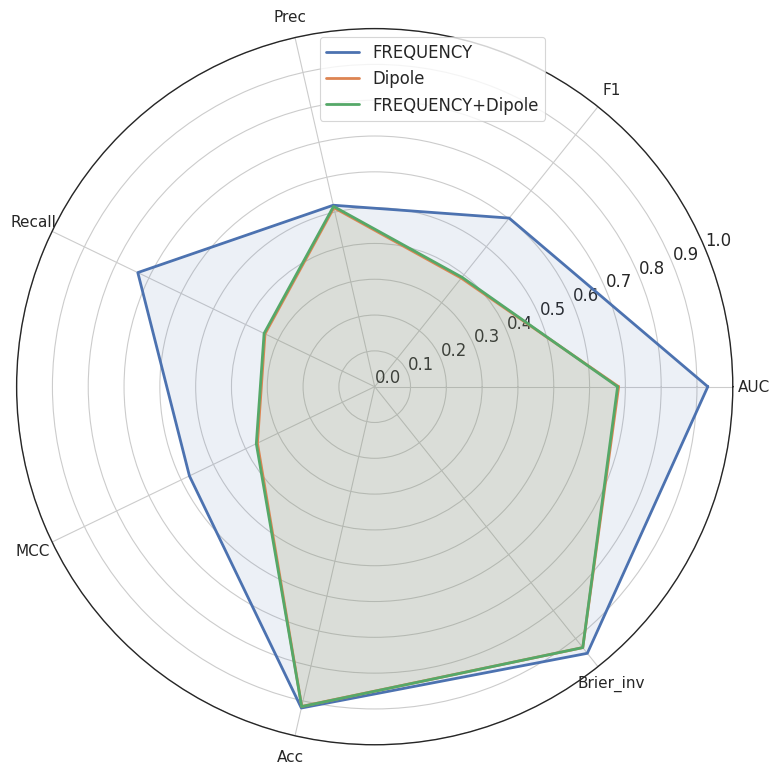

,AUC,F1,Prec,Recall,MCC,Acc,Brier,CM
Model,,,,,,,,
FREQUENCY,0.930+0.039,0.602+0.101,0.520+0.114,0.734+0.123,0.574+0.112,0.920+0.027,0.048,"[[751.2, 50.8], [18.6, 51.4]]"
Dipole,0.681+0.105,0.388+0.125,0.513+0.207,0.340+0.132,0.363+0.131,0.916+0.020,0.068,"[[774.8, 27.2], [46.2, 23.8]]"
FREQUENCY+Dipole,0.678+0.111,0.391+0.126,0.516+0.207,0.343+0.134,0.367+0.132,0.916+0.020,0.068,"[[775.0, 27.0], [46.0, 24.0]]"


In [87]:
import pandas as pd
import numpy as np
from scripts.plotting import plot_radar

metrics = ["AUC", "F1", "Prec", "Recall", "MCC", "Acc",]
tmetrics = metrics + ['Brier', 'CM']
dfs = {}

for metric in tmetrics:
    dfs[metric] = pd.read_csv(f"{args.results_dir}/resdata_{metric}_{dataset}_ITER{args.iter}.csv", index_col=0)
dfm = pd.DataFrame(columns = tmetrics, index = dfs[metric].columns)
dfmp = pd.DataFrame(columns = tmetrics, index = dfs[metric].columns)
dfm.index.name = "Model"
dfmp.index.name = "Model"
for method in dfs[metric].columns:
    values = []
    valuesp = []
    for metric in tmetrics:
        if metric == "CM":
            cm = dfs[metric][method].apply(lambda x: np.array(eval(x))).sum() / 5
            values += [cm]
            valuesp += [cm]
        elif metric == 'Brier':
            values += [1 - dfs[metric][method].mean()]
            valuesp += [f"{dfs[metric][method].mean():.3f}"]
        else:
            values += [dfs[metric][method].mean()]
            valuesp += [f"{dfs[metric][method].mean():.3f}+{dfs[metric][method].std():.3f}"]
    dfm.loc[method] = values
    dfmp.loc[method] = valuesp
dfm.rename(columns={"Brier": "Brier_inv"}, inplace=True)
fig = plot_radar(dfm, metrics + ['Brier_inv'])
dfmp

## Plot calibaration curves

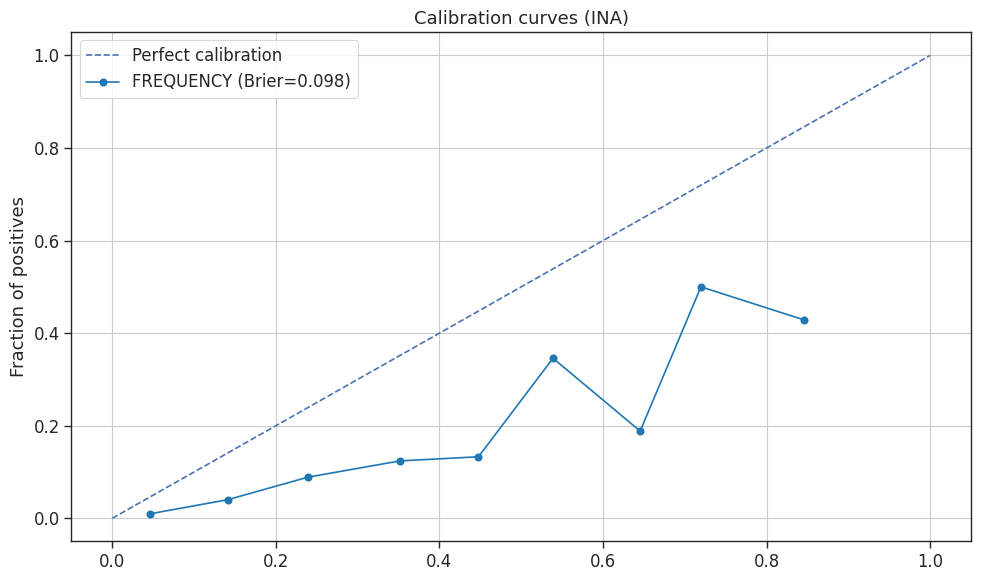

In [18]:
from scripts.plotting import plot_calibration
from scripts.utils import split_array
p_pred = {k:split_array(v)[0] for k,v in prob_pred.items()}
p_true = {k:list(v[0:len(p_pred[k])]) for k,v in prob_true.items()}
a_runs = {k:(v[0][0:1486], v[1][0:1486]) for k,v in all_runs.items()}
fig = plot_calibration(p_pred, p_true, a_runs,title=f"Calibration curves ({dataset})")